# Intro to Scikit Learn

## What is Machine Learning?

Machine Learning is the field of study that gives computers the ability to learn **without being explicitly programmed.**

## Types of ML

1. Supervised Learning: Predict based on labeled data (e.g., Classification, regression)
2. Unsupervised Learning: Discover patterns without labels(e.g., clustering)
3. Reinforcement Learning: Learn via rewards/punishments.

## The ML Workflow
|Number|Process|Description|
|-:|-|-|
1|Data Collection|Gather data(CSV, API, sensors, etc.)|
2|Data Preprocessing|Handle missing values, scale data|
3|Train/Test Split|Supervise training and testing data|
4|Model Training|Use algorithm to learn from training data|
5|Model Evaluation|Measure Accuracy, precision, recall|
6|Inference|Make predictions on raw data|

## What is Scikit-Learn?

- Python's most-used ML library for traditional models
- Built on NumPy, SciPy, and Matplotlib
- Provides API for:
  - Models (fit, predict)
  - Preprocessing
  - Evaluation
  - Pipelines


## 1. Loading Data with Scikit Learn

In [1]:
from sklearn.datasets import load_iris
iris = load_iris()

In [2]:
import pandas as pd
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target)
df = X.copy()
df['target'] = y # Create a new column
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


## 2. Visualizing dataset structure

### Class distribution

Text(0, 0.5, 'Count')

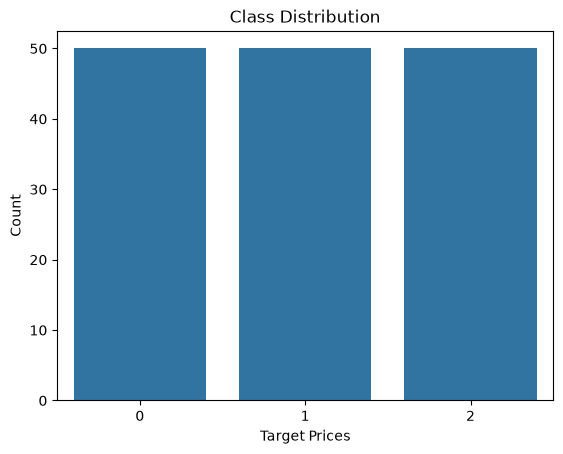

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x=df['target'])

plt.title('Class Distribution')
plt.xlabel('Target Prices')
plt.ylabel('Count')

### Pair-wise Feature Relationships

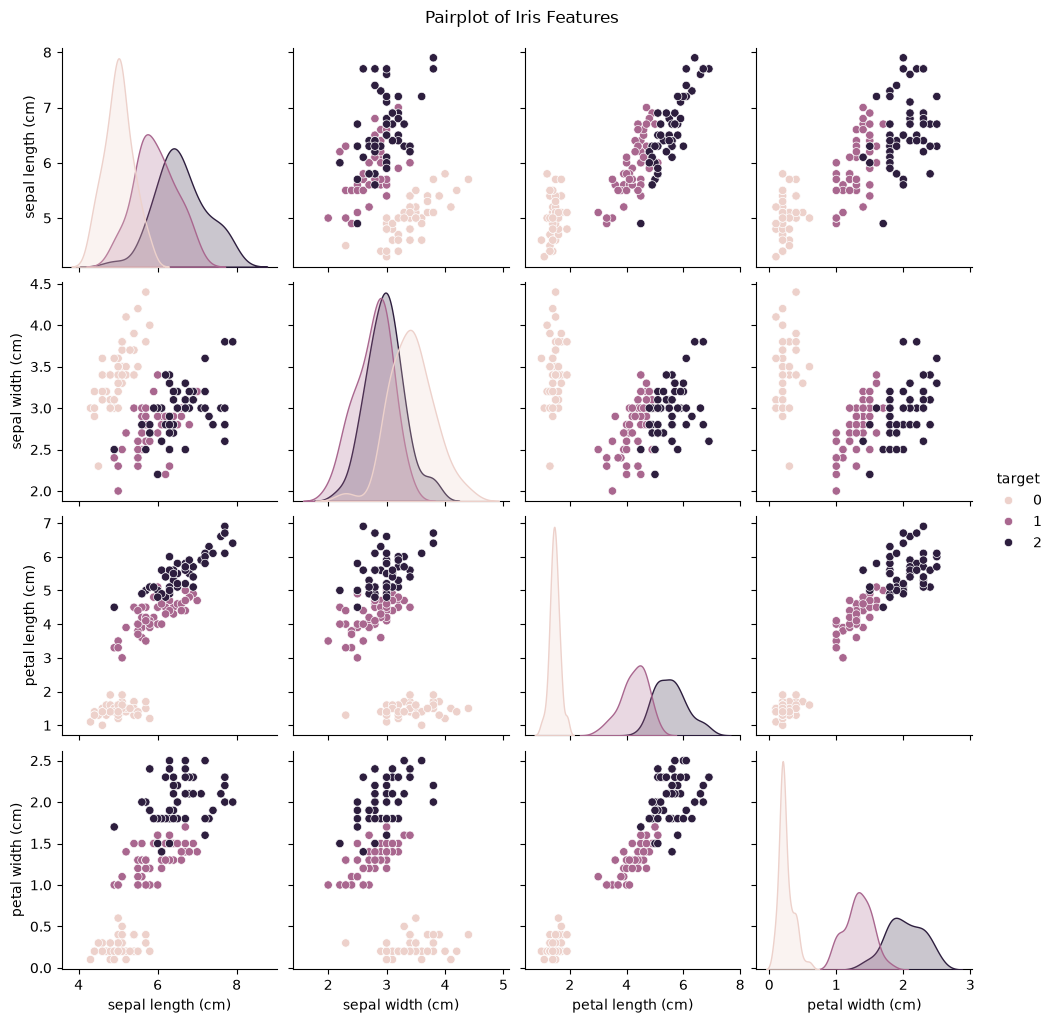

In [4]:
sns.pairplot(df, hue='target')
plt.suptitle("Pairplot of Iris Features", y=1.02)
plt.show()

### Corelation Map

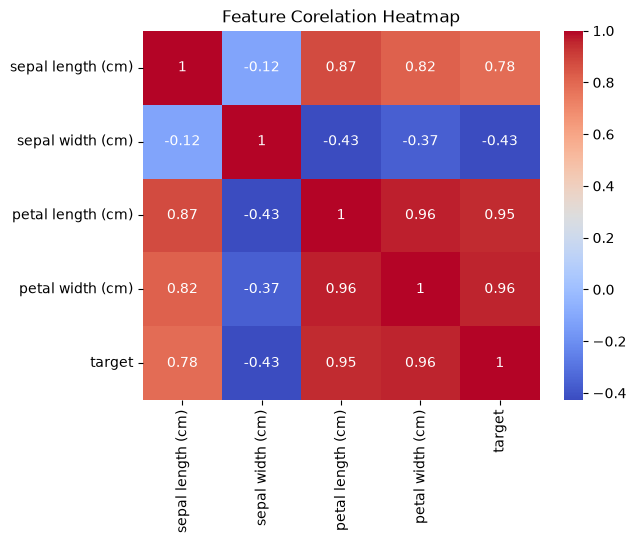

In [5]:
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Corelation Heatmap")
plt.show()

## 2. Data Preprocessing

### Why preprocess?
- ML models expect numeric data
- Feature should be scaled for models like KNN, SVM

### Creating the Dataset

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Scaling the dataset features / batch normalization - Makes the model performance **better**

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)

### Visualization of dataset before and after scaling

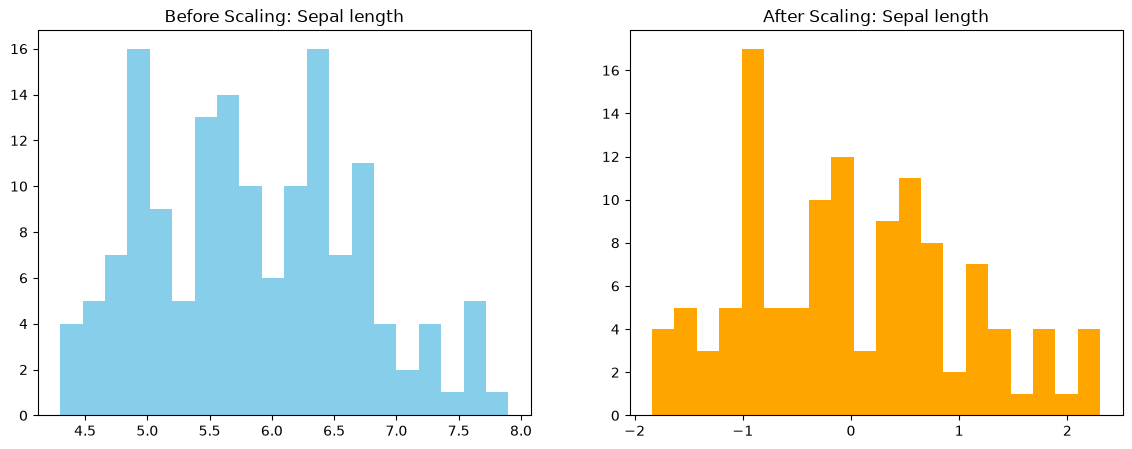

In [8]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1,2,figsize=(14,5))

ax[0].hist(X.iloc[:, 0], bins=20, color='skyblue')
ax[0].set_title('Before Scaling: Sepal length')

ax[1].hist(X_train[:, 0], bins=20, color='orange')
ax[1].set_title('After Scaling: Sepal length')
plt.show()

## 3. ML Models in Scikit-learn

### K-Nearest Neighbors

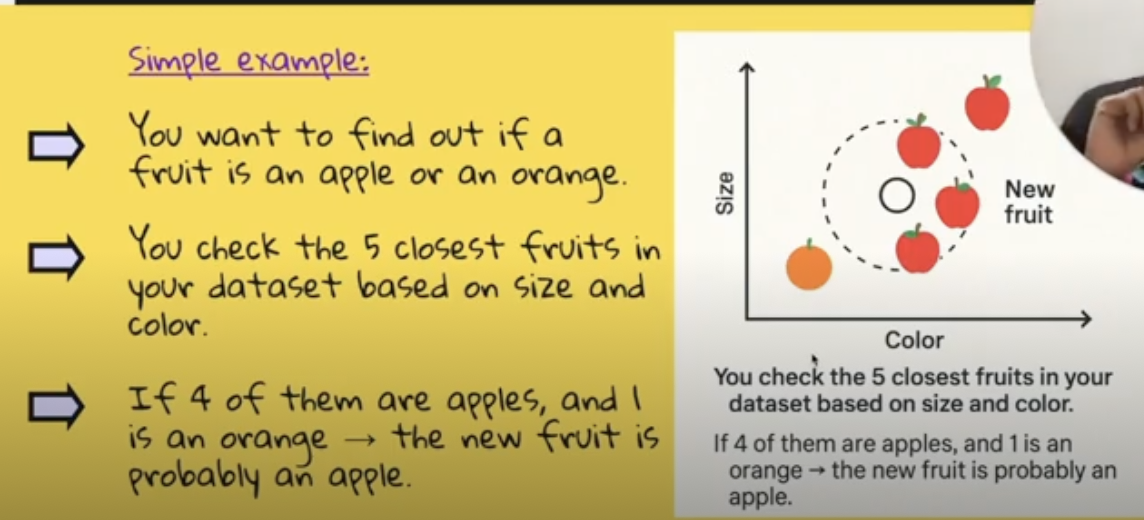

In [9]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
print(y_pred_knn)

[1 0 2 1 1 0 1 2 1 1 1 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]


### Decision Trees
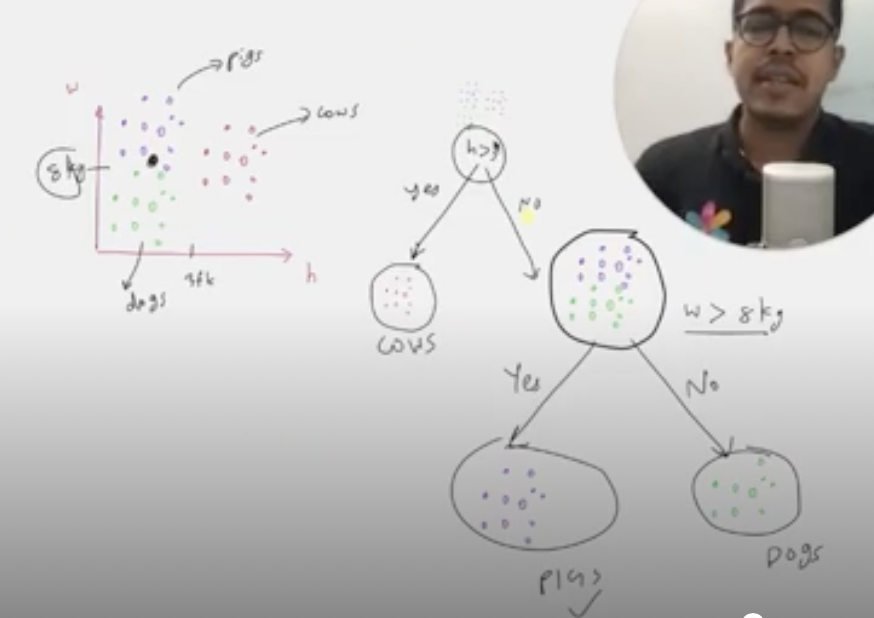

In [10]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(max_depth=3, random_state=42)
tree.fit(X_train, y_train)
y_pred_tree = tree.predict(X_test)
print(y_pred_tree)

[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 1 2 0 0]


## 4. Finalizing Model Evaluation

### Confusion Matrix Heatmap (for both models)

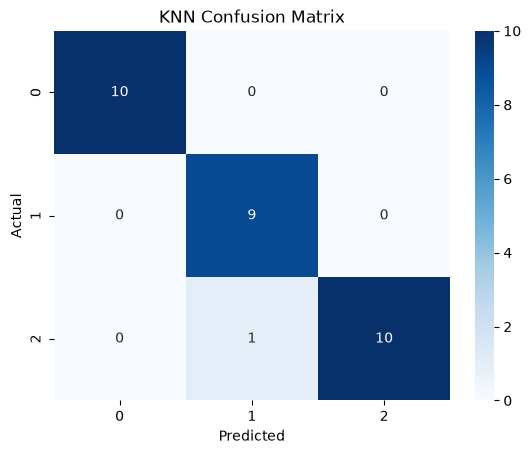

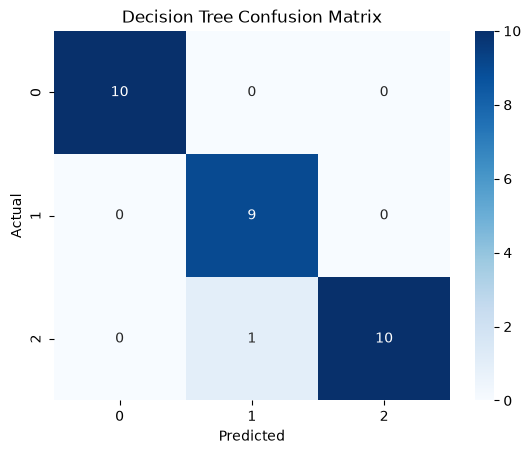

In [11]:
from sklearn.metrics import confusion_matrix, classification_report

def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(title)
    plt.show()

plot_confusion(y_test, y_pred_knn, "KNN Confusion Matrix")
plot_confusion(y_test, y_pred_tree, "Decision Tree Confusion Matrix")

In [12]:
print("KNN report:\n", classification_report(y_test, y_pred_knn))
print("Tree report:\n", classification_report(y_test, y_pred_tree))

KNN report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.90      1.00      0.95         9
           2       1.00      0.91      0.95        11

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30

Tree report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.90      1.00      0.95         9
           2       1.00      0.91      0.95        11

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30

